In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/EMG-data.csv')

df['channel2'] = pd.to_numeric(df['channel2'], errors='coerce')

df.dropna(inplace=True);

print("Dataset loaded successfully and initial cleaning performed. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully and initial cleaning performed. Displaying the first 5 rows:


/tmp/ipykernel_5919/2822857212.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/EMG-data.csv')


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0.0,1.0
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0.0,1.0
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0.0,1.0
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0.0,1.0
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0.0,1.0


In [7]:
import numpy as np
import pandas as pd
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# --- Re-running essential setup from previous cells to define dependencies ---

# Data Loading and Initial Cleaning (from Qk-fjQyr-gUE)
df = pd.read_csv('/content/EMG-data.csv')

# Convert all EMG channels to numeric, coercing errors, and then drop NaNs
emg_channels = [f'channel{i}' for i in range(1, 9)]
for col in emg_channels:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True);

# Filter for relevant labels (1.0, 2.0, 3.0) as identified in earlier context
df = df[df['label'].isin([1.0, 2.0, 3.0])].copy()

# Bandpass Filtering (from 293c8754)
sampling_freq = 1000
low_cut = 20.0
high_cut = 450.0

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

for col in emg_channels:
    df[f'{col}_filtered'] = bandpass_filter(df[col].values, low_cut, high_cut, sampling_freq)

# Normalization (from 7b635007)
scaler = StandardScaler()
df[[f'{col}_normalized' for col in emg_channels]] = scaler.fit_transform(df[[f'{col}_filtered' for col in emg_channels]])

# Segmentation and Feature Extraction (from e577a955)
window_size = 256
overlap = 128
features_list = []
labels_list = []

def extract_features(window):
    rms = np.sqrt(np.mean(window**2))
    mav = np.mean(np.abs(window))
    wl = np.sum(np.abs(np.diff(window)))
    zcr = np.sum(np.diff(np.sign(window) != 0).astype(int))
    return [rms, mav, wl, zcr]

for label_val in df['label'].unique():
    df_label = df[df['label'] == label_val]
    emg_data_normalized = df_label[[f'{col}_normalized' for col in emg_channels]].values
    num_samples = emg_data_normalized.shape[0]
    step_size = window_size - overlap

    for i in range(0, num_samples - window_size + 1, step_size):
        window_data = emg_data_normalized[i : i + window_size, :]
        window_features = []
        for channel_idx in range(window_data.shape[1]):
            channel_window = window_data[:, channel_idx]
            window_features.extend(extract_features(channel_window))
        features_list.append(window_features)
        labels_list.append(label_val)

feature_names = []
for col in emg_channels:
    feature_names.extend([f'{col}_RMS', f'{col}_MAV', f'{col}_WL', f'{col}_ZCR'])

X = pd.DataFrame(features_list, columns=feature_names)
y = pd.Series(labels_list, name='gesture_label')

# Label Encoding (from 8092e1b8)
label_mapping = {
    1.0: 'Open',
    2.0: 'Close',
    3.0: 'Grip'
}
y_categorical = y.map(label_mapping)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_categorical)

# Train-Test Split (from e952a2ce)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Model Training (Random Forest part from 59a2c479)
rf_model = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [20],
    'max_depth': [5],
    'min_samples_leaf': [2]
}
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=3, n_jobs=-1, verbose=0)
rf_grid_search.fit(X_train, y_train)
best_rf_model = rf_grid_search.best_estimator_

# --- Original content of VMM1nBhJx1IZ ---
print("--- Demonstrating Predictions with Best Random Forest Model ---")

sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_indices]
sample_y_true = y_test[sample_indices]

sample_y_pred = best_rf_model.predict(sample_X)
sample_y_proba = best_rf_model.predict_proba(sample_X)

print("Sample Predictions:")
for i, idx in enumerate(sample_indices):
    true_label = label_encoder.inverse_transform([sample_y_true[i]])[0]
    predicted_label = label_encoder.inverse_transform([sample_y_pred[i]])[0]
    confidence_scores = sample_y_proba[i]

    print(f"\nSample {i+1} (Original Index: {X_test.index[idx]}):")
    print(f"  True Label: {true_label}")
    print(f"  Predicted Label: {predicted_label}")
    print(f"  Confidence Scores: {confidence_scores}")

    predicted_class_index = sample_y_pred[i]
    print(f"  Confidence for '{predicted_label}': {confidence_scores[predicted_class_index]:.4f}")

--- Demonstrating Predictions with Best Random Forest Model ---
Sample Predictions:

Sample 1 (Original Index: 1285):
  True Label: Close
  Predicted Label: Close
  Confidence Scores: [0.94844304 0.00727851 0.04427844]
  Confidence for 'Close': 0.9484

Sample 2 (Original Index: 522):
  True Label: Open
  Predicted Label: Grip
  Confidence Scores: [0.13538232 0.45114847 0.4134692 ]
  Confidence for 'Grip': 0.4511

Sample 3 (Original Index: 1511):
  True Label: Close
  Predicted Label: Open
  Confidence Scores: [0.3231113  0.18232782 0.49456088]
  Confidence for 'Open': 0.4946

Sample 4 (Original Index: 2020):
  True Label: Grip
  Predicted Label: Grip
  Confidence Scores: [0.0383123  0.77940658 0.18228112]
  Confidence for 'Grip': 0.7794

Sample 5 (Original Index: 2025):
  True Label: Grip
  Predicted Label: Grip
  Confidence Scores: [0.01699546 0.95034299 0.03266155]
  Confidence for 'Grip': 0.9503


In [9]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 335910 entries, 0 to 335909
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   time                 335910 non-null  int64  
 1   channel1             335910 non-null  float64
 2   channel2             335910 non-null  float64
 3   channel3             335910 non-null  float64
 4   channel4             335910 non-null  float64
 5   channel5             335910 non-null  float64
 6   channel6             335910 non-null  float64
 7   channel7             335910 non-null  float64
 8   channel8             335910 non-null  float64
 9   class                335910 non-null  int64  
 10  label                335910 non-null  float64
 11  channel1_filtered    335910 non-null  float64
 12  channel2_filtered    335910 non-null  float64
 13  channel3_filtered    335910 non-null  float64
 14  channel4_filtered    335910 non-null  float64
 15  

In [10]:
print("\nChecking for missing values:")
display(df.isnull().sum())


Checking for missing values:


,0
time,0
channel1,0
channel2,0
channel3,0
channel4,0
channel5,0
channel6,0
channel7,0
channel8,0
class,0


In [11]:
print("\nChecking for duplicate rows:")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows dropped. New shape:", df.shape)


Checking for duplicate rows:
Number of duplicate rows: 0



Distribution of the target variable (gesture):


,count
label,
2.0,136426
1.0,121170
3.0,78314


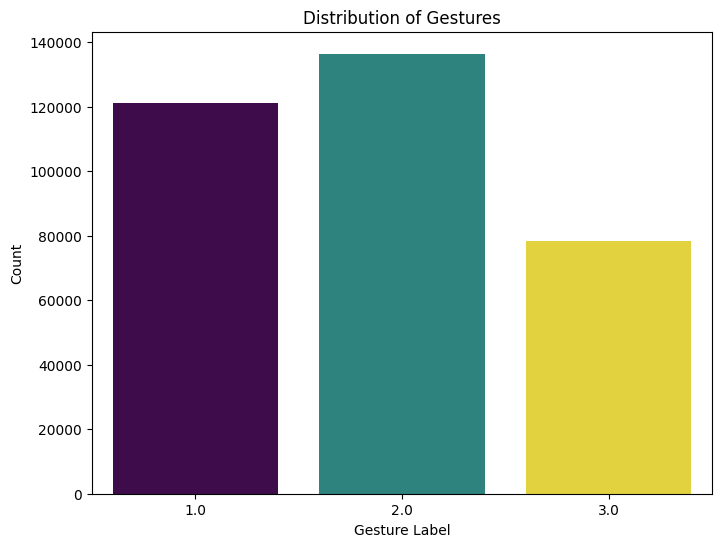

In [12]:
print("\nDistribution of the target variable (gesture):")
display(df['label'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribution of Gestures')
plt.xlabel('Gesture Label')
plt.ylabel('Count')
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42)

rf_param_grid = {
    'n_estimators': [20],
    'max_depth': [5],
    'min_samples_leaf': [2]
}

rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=3, n_jobs=-1, verbose=2)
rf_grid_search.fit(X_train, y_train)

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
best_rf_model = rf_grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

print("\n--- Training Support Vector Machine (SVC) ---")
svc_model = SVC(random_state=42, probability=True)

svc_param_grid = {
    'C': [0.1],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

svc_grid_search = GridSearchCV(estimator=svc_model, param_grid=svc_param_grid, cv=3, n_jobs=-1, verbose=2)
svc_grid_search.fit(X_train, y_train)

print("Best parameters for SVC:", svc_grid_search.best_params_)
best_svc_model = svc_grid_search.best_estimator_

y_pred_svc = best_svc_model.predict(X_test)
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print("SVC Classification Report:\n", classification_report(y_test, y_pred_svc))


--- Training Random Forest Classifier ---
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 20}
Random Forest Accuracy: 0.8447837150127226
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.94      0.88       328
           1       0.89      0.79      0.83       173
           2       0.86      0.77      0.81       285

    accuracy                           0.84       786
   macro avg       0.85      0.83      0.84       786
weighted avg       0.85      0.84      0.84       786


--- Training Support Vector Machine (SVC) ---
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for SVC: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
SVC Accuracy: 0.7811704834605598
SVC Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84     

In [14]:
from scipy.signal import butter, lfilter

emg_channels = [f'channel{i}' for i in range(1, 9)]

sampling_freq = 1000
low_cut = 20.0
high_cut = 450.0

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

print(f"Applying bandpass filter ({low_cut}-{high_cut} Hz) to EMG channels...")
for col in emg_channels:
    df[f'{col}_filtered'] = bandpass_filter(df[col].values, low_cut, high_cut, sampling_freq)

print("Filtering complete. Displaying first 5 rows with filtered channels:")
display(df[emg_channels + [f'{c}_filtered' for c in emg_channels]].head())

Applying bandpass filter (20.0-450.0 Hz) to EMG channels...
Filtering complete. Displaying first 5 rows with filtered channels:


,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,channel1_filtered,channel2_filtered,channel3_filtered,channel4_filtered,channel5_filtered,channel6_filtered,channel7_filtered,channel8_filtered
0,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0.000006,-0.000011,-0.000006,-0.000017,0.000000,-0.000006,0.000000,-0.000006
1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0.000008,-0.000017,-0.000008,-0.000025,0.000000,-0.000008,0.000000,-0.000008
2,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,-0.000009,0.000011,0.000014,0.000009,0.000006,-0.000008,-0.000006,0.000009
3,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,-0.000015,0.000021,0.000023,0.000019,0.000008,-0.000011,-0.000008,0.000015
4,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,-0.000005,0.000007,0.000008,0.000007,0.000003,-0.000003,-0.000003,0.000005


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("Applying StandardScaler to filtered EMG channels...")
df[[f'{col}_normalized' for col in emg_channels]] = scaler.fit_transform(df[[f'{col}_filtered' for col in emg_channels]])

print("Normalization complete. Displaying first 5 rows with normalized channels:")
display(df[[f'{c}_normalized' for c in emg_channels]].head())

print("\nMean of normalized channels:")
print(df[[f'{c}_normalized' for c in emg_channels]].mean())
print("\nStandard deviation of normalized channels:")
print(df[[f'{c}_normalized' for c in emg_channels]].std())

Applying StandardScaler to filtered EMG channels...
Normalization complete. Displaying first 5 rows with normalized channels:


,channel1_normalized,channel2_normalized,channel3_normalized,channel4_normalized,channel5_normalized,channel6_normalized,channel7_normalized,channel8_normalized
0,0.047532,-0.101771,-0.062764,-0.118581,0.000004,-0.048460,-0.000004,-0.062827
1,0.071032,-0.152035,-0.093774,-0.177167,0.000004,-0.072402,-0.000004,-0.093868
2,-0.072381,0.103843,0.158240,0.061780,0.038885,-0.071680,-0.055476,0.095566
3,-0.123545,0.188147,0.256763,0.130750,0.058093,-0.091379,-0.082880,0.163149
4,-0.043018,0.067535,0.086797,0.050346,0.018633,-0.025865,-0.026582,0.056780



Mean of normalized channels:
channel1_normalized    2.432569e-19
channel2_normalized    4.145943e-18
channel3_normalized    2.455705e-18
channel4_normalized   -3.701735e-19
channel5_normalized   -1.924902e-18
channel6_normalized    4.759374e-19
channel7_normalized   -5.774707e-18
channel8_normalized    3.278680e-19
dtype: float64

Standard deviation of normalized channels:
channel1_normalized    1.000001
channel2_normalized    1.000001
channel3_normalized    1.000001
channel4_normalized    1.000001
channel5_normalized    1.000001
channel6_normalized    1.000001
channel7_normalized    1.000001
channel8_normalized    1.000001
dtype: float64


In [16]:
window_size = 256
overlap = 128

features_list = []
labels_list = []

print("Performing segmentation and feature extraction...")

def extract_features(window):
    rms = np.sqrt(np.mean(window**2))
    mav = np.mean(np.abs(window))
    wl = np.sum(np.abs(np.diff(window)))
    zcr = np.sum(np.diff(np.sign(window) != 0).astype(int))
    return [rms, mav, wl, zcr]

for label_val in df['label'].unique():
    df_label = df[df['label'] == label_val]

    emg_data_normalized = df_label[[f'{col}_normalized' for col in emg_channels]].values

    num_samples = emg_data_normalized.shape[0]
    step_size = window_size - overlap

    for i in range(0, num_samples - window_size + 1, step_size):
        window_data = emg_data_normalized[i : i + window_size, :]

        window_features = []
        for channel_idx in range(window_data.shape[1]):
            channel_window = window_data[:, channel_idx]
            window_features.extend(extract_features(channel_window))

        features_list.append(window_features)
        labels_list.append(label_val)

feature_names = []
for col in emg_channels:
    feature_names.extend([f'{col}_RMS', f'{col}_MAV', f'{col}_WL', f'{col}_ZCR'])

X = pd.DataFrame(features_list, columns=feature_names)
y = pd.Series(labels_list, name='gesture_label')

print("Feature extraction complete. Displaying the first 5 rows of features:")
display(X.head())
print("\nDistribution of extracted labels:")
display(y.value_counts())

Performing segmentation and feature extraction...
Feature extraction complete. Displaying the first 5 rows of features:


,channel1_RMS,channel1_MAV,channel1_WL,channel1_ZCR,channel2_RMS,channel2_MAV,channel2_WL,channel2_ZCR,channel3_RMS,channel3_MAV,...,channel6_WL,channel6_ZCR,channel7_RMS,channel7_MAV,channel7_WL,channel7_ZCR,channel8_RMS,channel8_MAV,channel8_WL,channel8_ZCR
0,0.089937,0.065385,8.721396,0,0.194062,0.131491,19.002432,0,0.289950,0.213189,...,5.469406,0,0.078998,0.057160,7.551693,0,0.075612,0.054069,7.698260,0
1,0.094544,0.069316,8.563600,0,0.154121,0.111702,13.981514,0,0.207179,0.145702,...,4.196750,0,0.075378,0.052914,7.172272,0,0.090256,0.061485,7.549936,0
2,0.068026,0.046890,6.046497,0,0.138621,0.097822,11.367631,0,0.196540,0.136905,...,5.790571,0,0.055683,0.040808,4.694750,0,0.089169,0.062706,7.270769,0
3,0.079220,0.049634,6.948014,0,0.138709,0.097893,11.453048,0,0.195281,0.135771,...,8.330556,0,0.069568,0.049860,6.190871,0,0.074017,0.053558,6.945300,0
4,0.080840,0.052841,7.314262,0,0.130325,0.088994,11.577149,0,0.152230,0.109524,...,6.873736,0,0.084986,0.065934,8.104418,0,0.086520,0.065212,8.028595,0



Distribution of extracted labels:


,count
gesture_label,
2.0,1064
1.0,945
3.0,610


In [17]:
from sklearn.preprocessing import LabelEncoder

label_mapping = {
    1.0: 'Open',
    2.0: 'Close',
    3.0: 'Grip'
}

y_categorical = y.map(label_mapping)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_categorical)

print("Original labels:", y_categorical.unique())
print("Encoded labels:", label_encoder.classes_)
print("\nDisplaying first 5 encoded labels:")
display(y_encoded[:5])
print("\nDistribution of encoded labels:")
display(pd.Series(y_encoded).value_counts())

Original labels: ['Open' 'Close' 'Grip']
Encoded labels: ['Close' 'Grip' 'Open']

Displaying first 5 encoded labels:


array([2, 2, 2, 2, 2])


Distribution of encoded labels:


,count
0,1064
2,945
1,610


Visualizing raw vs. filtered EMG signals for a sample from 'Open' gesture...


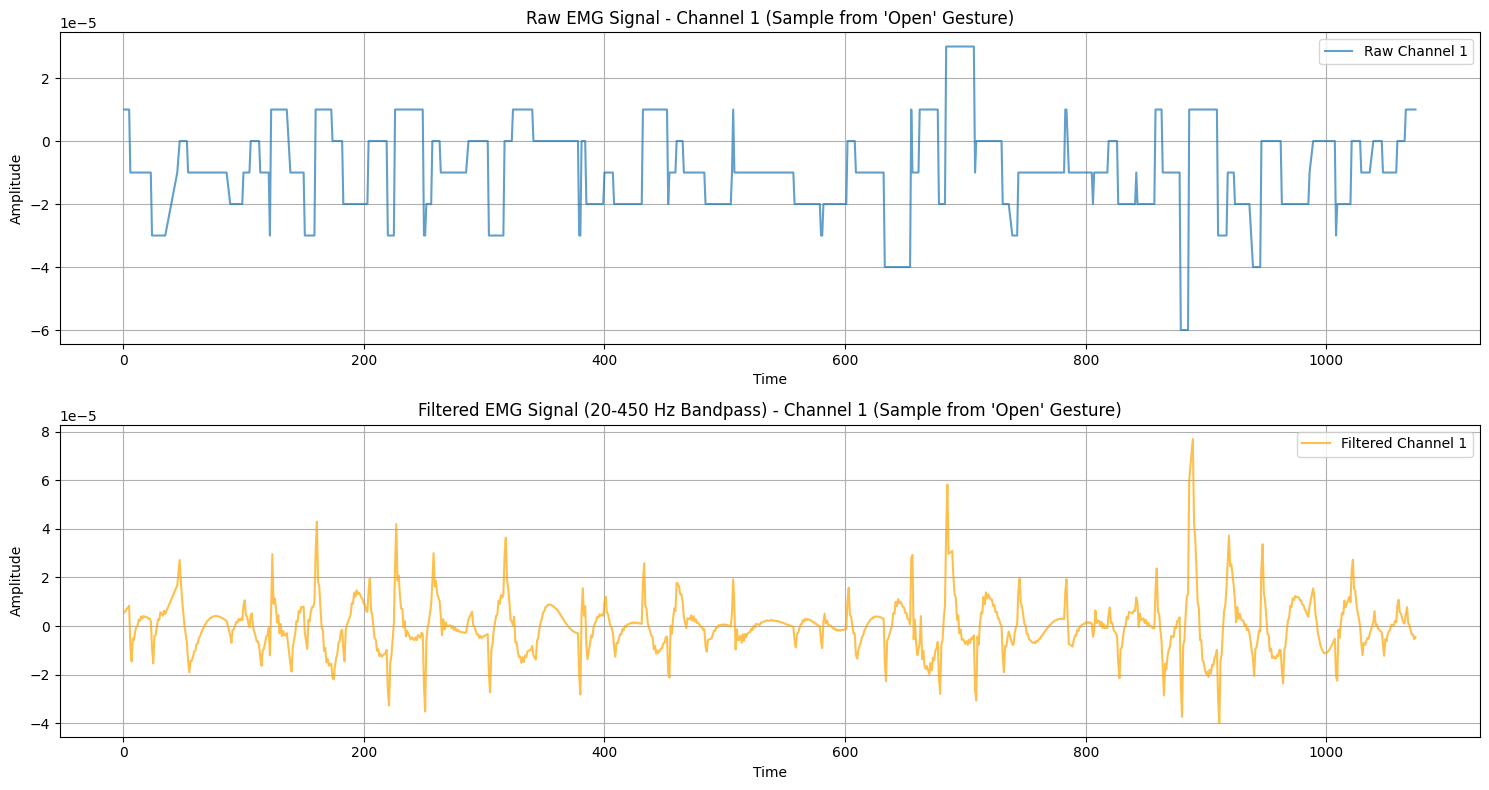


Visualizing normalized EMG signals for different gestures (Channel 1)...


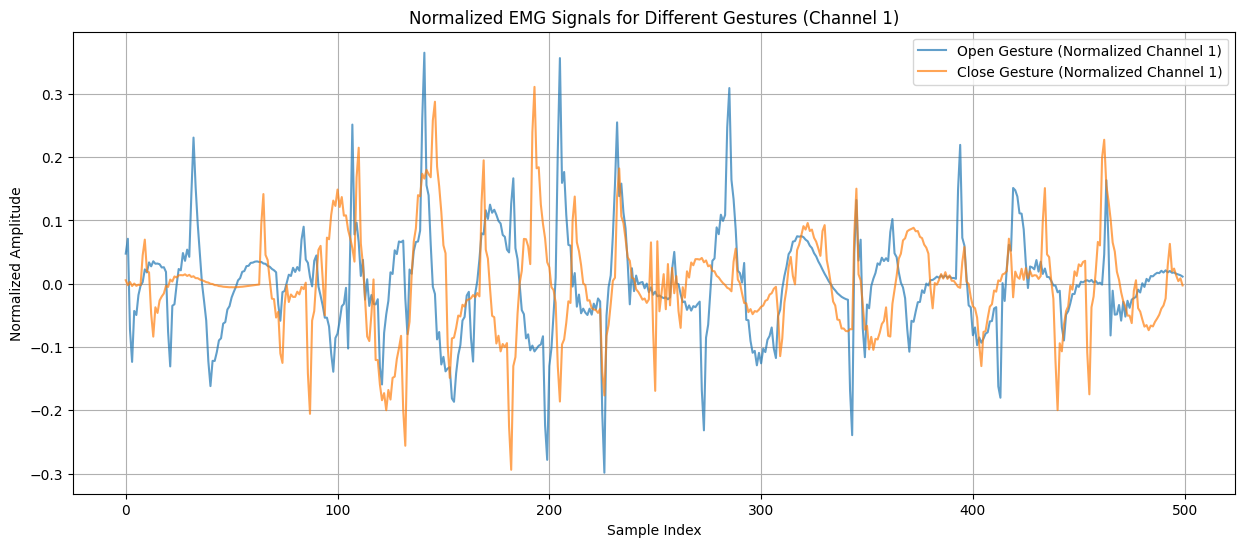

In [18]:
print("Visualizing raw vs. filtered EMG signals for a sample from 'Open' gesture...")

sample_open_df = df[df['label'] == 1.0].head(1000)

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(sample_open_df['time'], sample_open_df['channel1'], label='Raw Channel 1', alpha=0.7)
plt.title("Raw EMG Signal - Channel 1 (Sample from 'Open' Gesture)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(sample_open_df['time'], sample_open_df['channel1_filtered'], label='Filtered Channel 1', color='orange', alpha=0.7)
plt.title("Filtered EMG Signal (20-450 Hz Bandpass) - Channel 1 (Sample from 'Open' Gesture)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nVisualizing normalized EMG signals for different gestures (Channel 1)...")

sample_open_norm = df[df['label'] == 1.0]['channel1_normalized'].iloc[0:500].values
sample_close_norm = df[df['label'] == 2.0]['channel1_normalized'].iloc[0:500].values

plt.figure(figsize=(15, 6))
plt.plot(sample_open_norm, label='Open Gesture (Normalized Channel 1)', alpha=0.7)
plt.plot(sample_close_norm, label='Close Gesture (Normalized Channel 1)', alpha=0.7)
plt.title('Normalized EMG Signals for Different Gestures (Channel 1)')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Amplitude')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of gestures in training set:")
display(pd.Series(y_train).value_counts(normalize=True))

print("\nDistribution of gestures in test set:")
display(pd.Series(y_test).value_counts(normalize=True))

Shape of X_train: (1833, 32)
Shape of X_test: (786, 32)
Shape of y_train: (1833,)
Shape of y_test: (786,)

Distribution of gestures in training set:


,proportion
0,0.401528
2,0.360065
1,0.238407



Distribution of gestures in test set:


,proportion
0,0.417303
2,0.362595
1,0.220102



--- Evaluating Models: Confusion Matrices ---


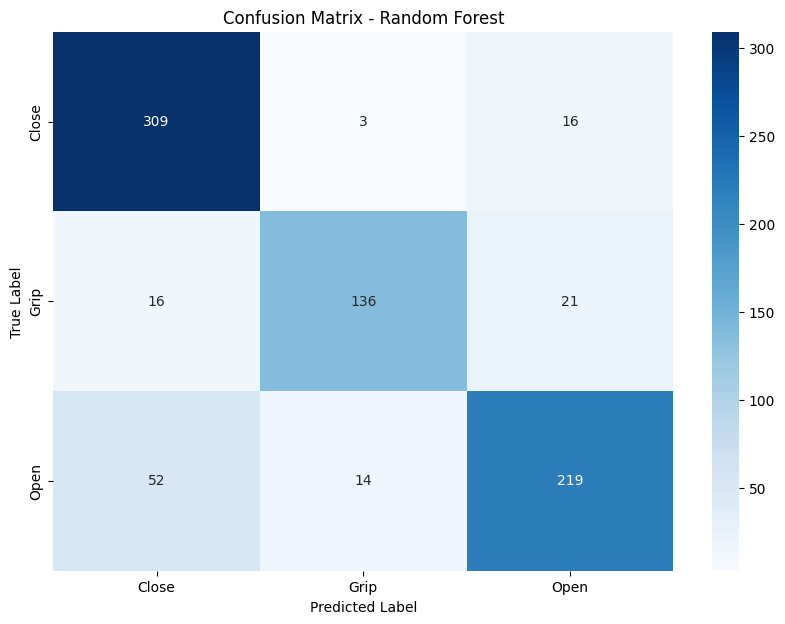

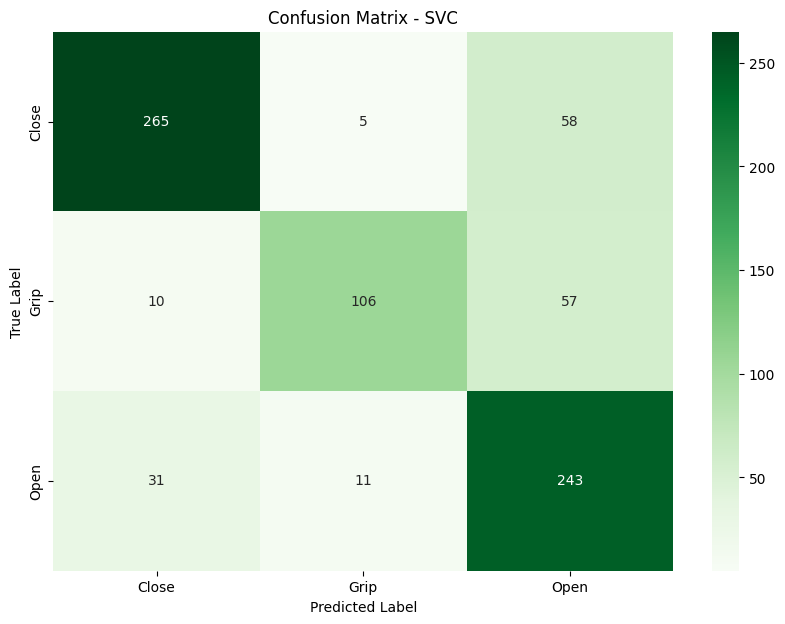

In [20]:
print("\n--- Evaluating Models: Confusion Matrices ---")

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [21]:
print("\n--- Demonstrating Predictions with Best Random Forest Model ---")

sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_indices]
sample_y_true = y_test[sample_indices]

sample_y_pred = best_rf_model.predict(sample_X)
sample_y_proba = best_rf_model.predict_proba(sample_X)

print("Sample Predictions:")
for i, idx in enumerate(sample_indices):
    true_label = label_encoder.inverse_transform([sample_y_true[i]])[0]
    predicted_label = label_encoder.inverse_transform([sample_y_pred[i]])[0]
    confidence_scores = sample_y_proba[i]

    print(f"\nSample {i+1} (Original Index: {X_test.index[idx]}):")
    print(f"  True Label: {true_label}")
    print(f"  Predicted Label: {predicted_label}")
    print(f"  Confidence Scores: {confidence_scores}")

    predicted_class_index = sample_y_pred[i]
    print(f"  Confidence for '{predicted_label}': {confidence_scores[predicted_class_index]:.4f}")


--- Demonstrating Predictions with Best Random Forest Model ---
Sample Predictions:

Sample 1 (Original Index: 926):
  True Label: Open
  Predicted Label: Open
  Confidence Scores: [0.10618823 0.09347261 0.80033916]
  Confidence for 'Open': 0.8003

Sample 2 (Original Index: 1557):
  True Label: Close
  Predicted Label: Close
  Confidence Scores: [0.78702934 0.06259617 0.1503745 ]
  Confidence for 'Close': 0.7870

Sample 3 (Original Index: 1905):
  True Label: Close
  Predicted Label: Close
  Confidence Scores: [0.75590163 0.03421645 0.20988192]
  Confidence for 'Close': 0.7559

Sample 4 (Original Index: 2608):
  True Label: Grip
  Predicted Label: Grip
  Confidence Scores: [0.03642536 0.81437699 0.14919765]
  Confidence for 'Grip': 0.8144

Sample 5 (Original Index: 1954):
  True Label: Close
  Predicted Label: Close
  Confidence Scores: [0.84271492 0.03224866 0.12503642]
  Confidence for 'Close': 0.8427


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42);

rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=3, n_jobs=-1, verbose=2)
rf_grid_search.fit(X_train, y_train);

print("Best parameters for Random Forest:", rf_grid_search.best_params_)
best_rf_model = rf_grid_search.best_estimator_;

y_pred_rf = best_rf_model.predict(X_test);
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

print("\n--- Training Support Vector Machine (SVC) ---")
svc_model = SVC(random_state=42, probability=True);

svc_param_grid = {
    'C': [0.1, 1],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

svc_grid_search = GridSearchCV(estimator=svc_model, param_grid=svc_param_grid, cv=3, n_jobs=-1, verbose=2)
svc_grid_search.fit(X_train, y_train);

print("Best parameters for SVC:", svc_grid_search.best_params_)
best_svc_model = svc_grid_search.best_estimator_;

y_pred_svc = best_svc_model.predict(X_test);
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print("SVC Classification Report:\n", classification_report(y_test, y_pred_svc))


--- Training Random Forest Classifier ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
Random Forest Accuracy: 0.9274809160305344
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       328
           1       0.93      0.88      0.90       173
           2       0.93      0.91      0.92       285

    accuracy                           0.93       786
   macro avg       0.93      0.92      0.92       786
weighted avg       0.93      0.93      0.93       786


--- Training Support Vector Machine (SVC) ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters for SVC: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVC Accuracy: 0.8854961832061069
SVC Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92   

Visualizing distribution of extracted features...


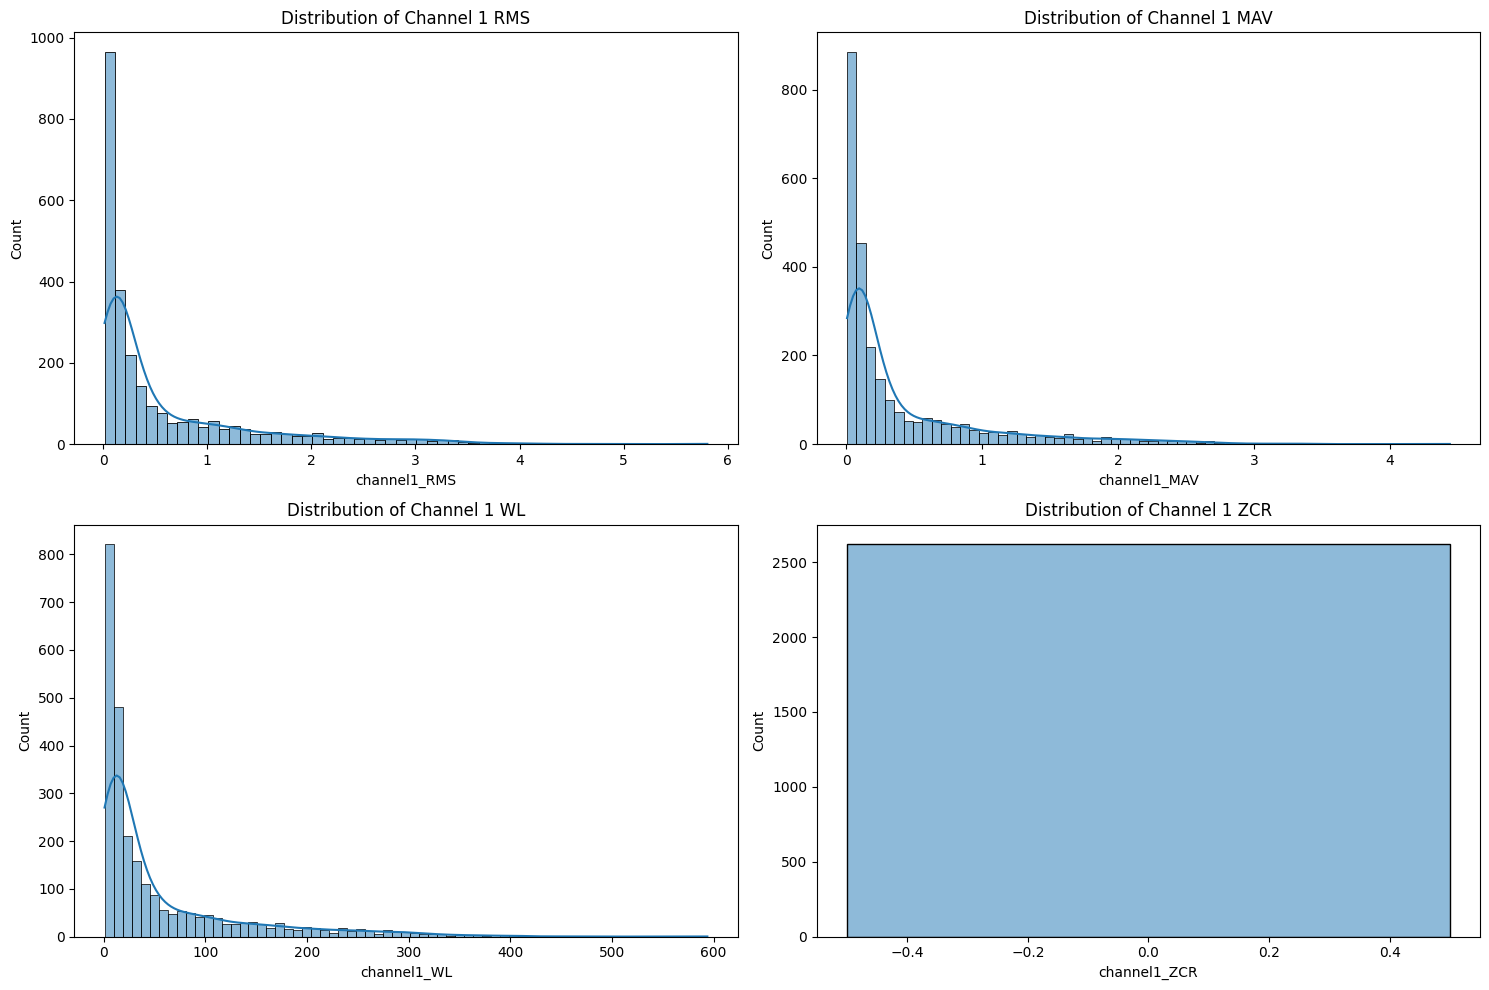


Reconfirming distribution of encoded gesture labels:


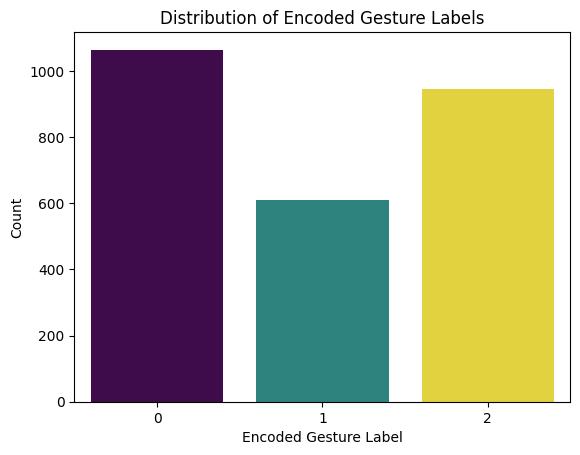

Encoded Label Map: ['Close' 'Grip' 'Open']


In [23]:
print("Visualizing distribution of extracted features...")

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(X['channel1_RMS'], kde=True)
plt.title('Distribution of Channel 1 RMS')

plt.subplot(2, 2, 2)
sns.histplot(X['channel1_MAV'], kde=True)
plt.title('Distribution of Channel 1 MAV')

plt.subplot(2, 2, 3)
sns.histplot(X['channel1_WL'], kde=True)
plt.title('Distribution of Channel 1 WL')

plt.subplot(2, 2, 4)
sns.histplot(X['channel1_ZCR'], kde=True)
plt.title('Distribution of Channel 1 ZCR')

plt.tight_layout()
plt.show()

print("\nReconfirming distribution of encoded gesture labels:")
encoded_label_df = pd.DataFrame(y_encoded, columns=['Encoded Label'])
sns.countplot(x='Encoded Label', data=encoded_label_df, palette='viridis', hue='Encoded Label', legend=False)
plt.title('Distribution of Encoded Gesture Labels')
plt.xlabel('Encoded Gesture Label')
plt.ylabel('Count')
plt.show()

print(f"Encoded Label Map: {label_encoder.inverse_transform(np.unique(y_encoded))}")